# Inicjalizacja | Feature Engineering | XGBoost

In [1]:
import pandas as pd
import numpy as np
import glob
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib

print("="*80)
print(">>> KROK 1: INICJALIZACJA, INŻYNIERIA CECH I TRENING XGBOOST <<<")
print("="*80)

# ==========================================
# 1. WCZYTANIE DANYCH 
# ==========================================
df_train_raw = pd.read_csv('../dane/gotowe_ml/honeypot_ml_ready.csv', low_memory=False)

classes_to_drop = ['Background Noise', 'Rare / Minor Anomalies']
df_train_raw = df_train_raw[~df_train_raw['Refined_Label'].isin(classes_to_drop)].copy()

test_files = glob.glob('../dane/testowe/*.csv')
dfs_test = [pd.read_csv(f, on_bad_lines="skip", low_memory=False) for f in test_files]
df_test_raw = pd.concat(dfs_test, ignore_index=True) if dfs_test else pd.DataFrame()

print(f"[*] Wczytano Złoty Standard (Tylko czyste kampanie): {len(df_train_raw)} rekordów.")
if not df_test_raw.empty:
    print(f"[*] Wczytano Surowe Logi (Przyszłość): {len(df_test_raw)} rekordów.")

# ==========================================
# 2. DEFINICJA CECH
# ==========================================
FEATURES = [
    'Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 
    'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio', 
    'is_well_known_port', 'is_ephemeral_port',
    'Proto_Enc', 'State_Enc', 'Dport_Num'
]

known_protos = {p: i for i, p in enumerate(df_train_raw['Proto'].astype(str).unique())}
known_states = {s: i for i, s in enumerate(df_train_raw['State'].astype(str).unique())}

def safe_encode(val, mapping_dict): return mapping_dict.get(str(val), -1)
def safe_port(p):
    try: return int(str(p), 16) if str(p).startswith('0x') else int(float(p))
    except: return 0

# ==========================================
# 3. PRZYGOTOWANIE ZBIORU TRENINGOWEGO 
# ==========================================
print("\n[*] Formowanie wektorów dla XGBoost...")
df_train = df_train_raw.copy()
df_train['Proto_Enc'] = df_train['Proto'].apply(lambda x: safe_encode(x, known_protos))
df_train['State_Enc'] = df_train['State'].apply(lambda x: safe_encode(x, known_states))
df_train['Dport_Num'] = df_train['Dport'].apply(safe_port)

X_train_full = df_train[FEATURES].fillna(0)

# Kodowanie etykiet (Wymóg XGBoosta - musi mieć od 0 do N-1)
le_target = LabelEncoder()
y_train_full_encoded = le_target.fit_transform(df_train['Refined_Label'])

# Zapisujemy LabelEncoder, żeby potem w Notatniku 05 móc odkodować wyniki!
joblib.dump(le_target, '../modele/label_encoder.joblib')

# Podział losowy na Train i Val (Ewaluacja separowalności)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full_encoded, test_size=0.2, random_state=42, stratify=y_train_full_encoded
)
print(f"[*] Podział stratyfikowany (każda klasa jest reprezentowana):")
print(f"    - Trening wewnętrzny: {len(X_train)} próbek")
print(f"    - Walidacja wewnętrzna: {len(X_val)} próbek")

# ==========================================
# 4. FUNKCJA DLA SUROWYCH DANYCH Z PRZYSZŁOŚCI 
# ==========================================
def prepare_future_logs(df_input):
    df = df_input.copy()
    
    for col in ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 'SrcBytes', 'DstBytes']:
        df[col] = pd.to_numeric(df.get(col, 0), errors='coerce').fillna(0)
        
    df['Bytes_per_Pkt'] = df['TotBytes'] / (df['TotPkts'] + 1e-6)
    df['Pkts_Freq']     = df['TotPkts'] / (df['Dur'] + 1e-6)
    df['Pkts_Ratio']    = df['SrcPkts'] / (df['DstPkts'] + 1e-6)
    df['Bytes_Ratio']   = df.get('SrcBytes', 0) / (df.get('DstBytes', 0) + 1e-6)

    df['Dport_Num'] = df.get('Dport', 0).apply(safe_port)
    df['is_well_known_port'] = ((df['Dport_Num'] > 0) & (df['Dport_Num'] <= 1024)).astype(int)
    df['is_ephemeral_port'] = (df['Dport_Num'] >= 49152).astype(int)

    cols_to_log = ['Dur', 'TotPkts', 'TotBytes', 'SrcPkts', 'DstPkts', 
                   'Bytes_per_Pkt', 'Pkts_Freq', 'Pkts_Ratio', 'Bytes_Ratio']
    for col in cols_to_log:
        df[col] = np.log1p(df[col].clip(lower=0))

    df['Proto_Enc'] = df.get('Proto', '').astype(str).apply(lambda x: safe_encode(x, known_protos))
    df['State_Enc'] = df.get('State', '').astype(str).apply(lambda x: safe_encode(x, known_states))
    
    for f in FEATURES:
        if f not in df.columns: df[f] = 0
    return df[FEATURES].fillna(0)

# ==========================================
# 5. TRENING MODELU WALIDACYJNEGO (XGBOOST)
# ==========================================
print("\n[*] Trenowanie modelu XGBoost (Gradient Boosting)...")

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

xgb_clf_val = xgb.XGBClassifier(
    n_estimators=300,          
    learning_rate=0.1,         
    max_depth=6,               
    random_state=42, 
    n_jobs=-1, 
    eval_metric='mlogloss',
    tree_method='hist'         
)

xgb_clf_val.fit(X_train, y_train, sample_weight=sample_weights)

# Szybki check wewnętrzny
y_pred_val = xgb_clf_val.predict(X_val)
acc = (y_pred_val == y_val).mean()
print(f"[+] Model XGBoost uzbrojony! Precyzja walidacyjna (Złoty Standard): {acc*100:.2f}%\n")

>>> KROK 1: INICJALIZACJA, INŻYNIERIA CECH I TRENING XGBOOST <<<
[*] Wczytano Złoty Standard (Tylko czyste kampanie): 132831 rekordów.

[*] Formowanie wektorów dla XGBoost...
[*] Podział stratyfikowany (każda klasa jest reprezentowana):
    - Trening wewnętrzny: 106264 próbek
    - Walidacja wewnętrzna: 26567 próbek

[*] Trenowanie modelu XGBoost (Gradient Boosting)...
[+] Model XGBoost uzbrojony! Precyzja walidacyjna (Złoty Standard): 99.99%



# Ewaluacja | Trening Produkcyjny | Zapis

>>> KROK 2: EWALUACJA WEWNĘTRZNA I WIZUALIZACJA (XGBOOST) <<<
[*] Generowanie raportu klasyfikacji (Precision, Recall, F1-Score)...

               RAPORT KLASYFIKACJI - XGBOOST (EWALUACJA HOLD-OUT)               
                                    precision    recall  f1-score   support

                BACnet Enumeration     0.8571    1.0000    0.9231         6
            BitTorrent Enumeration     1.0000    1.0000    1.0000        11
               CHARGEN Enumeration     1.0000    1.0000    1.0000         8
                  CoAP Enumeration     1.0000    1.0000    1.0000        14
                   DNS Enumeration     1.0000    1.0000    1.0000        51
                  HTTP Brute Force     1.0000    1.0000    1.0000        15
       HTTP Cross-Protocol Anomaly     1.0000    1.0000    1.0000        16
                 HTTPS Enumeration     1.0000    1.0000    1.0000         6
              HTTP_Alt Enumeration     1.0000    1.0000    1.0000         6
        HTTP_Alt_Admin Br

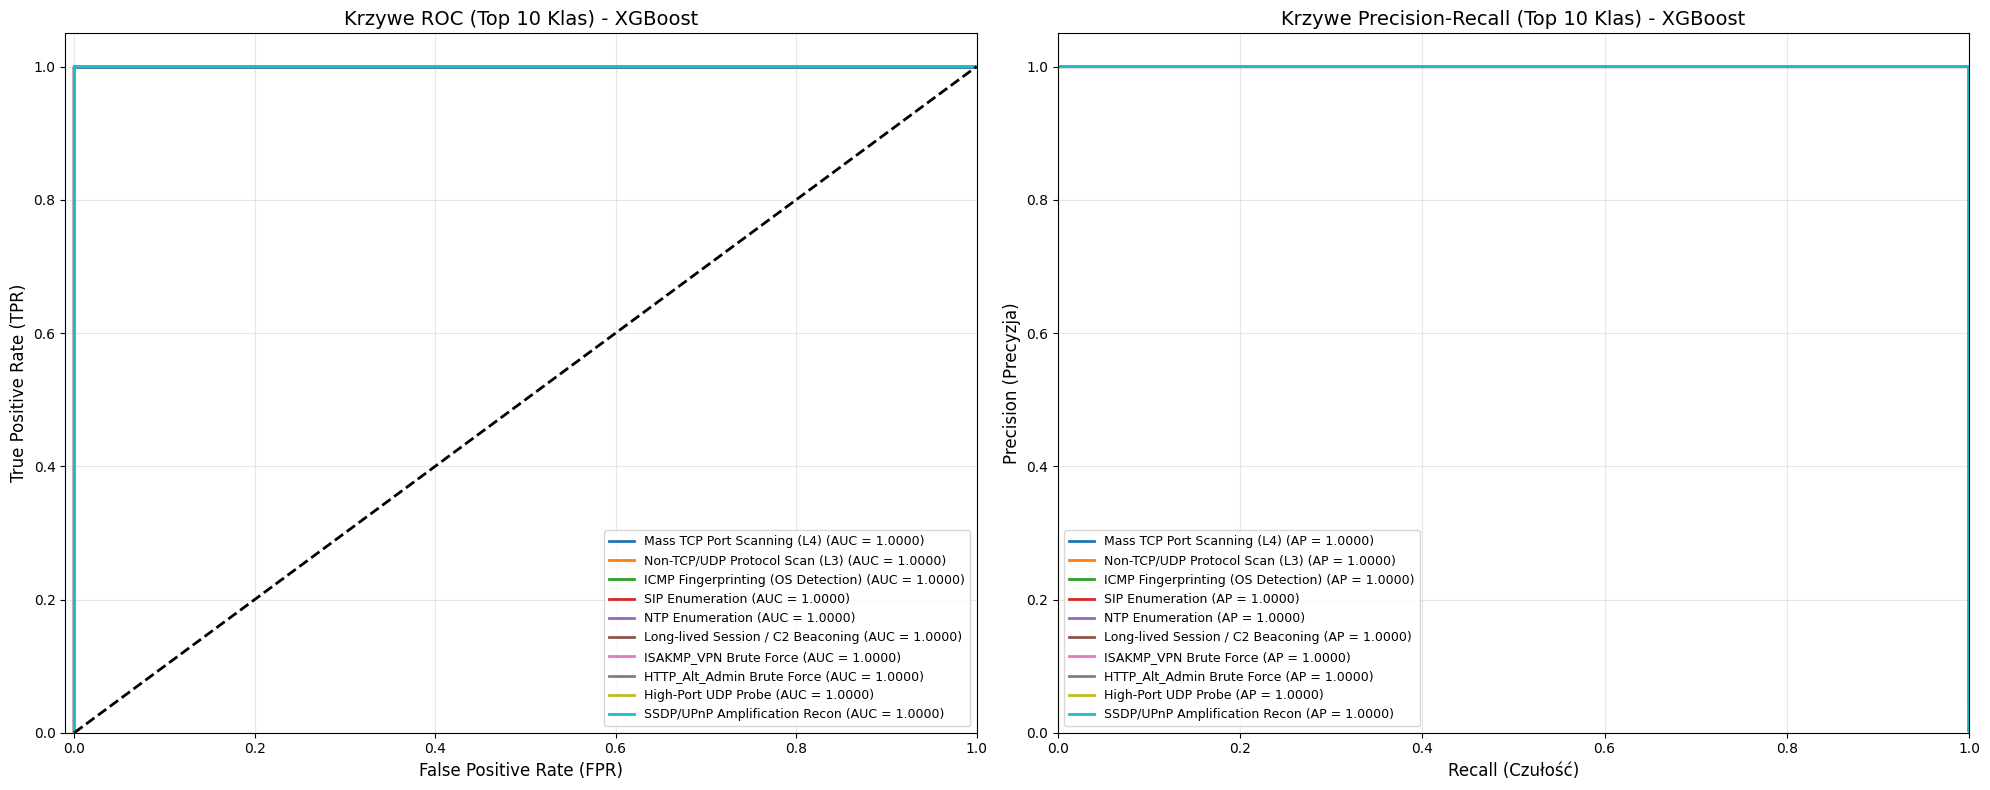


>>> KROK 3: TRENING MODELU PRODUKCYJNEGO I ZAPIS NA DYSK <<<
[*] Konsolidacja danych: Trenowanie ostatecznego XGBoosta na 100% Złotego Standardu...
[+] SUKCES! Model produkcyjny wygenerowany i zabezpieczony w: ../modele\xgb_production_model.joblib
[+] System przygotowany na starcie na Arenie Zero-Day (Notatnik 05)!


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, classification_report
from sklearn.preprocessing import label_binarize
import os
import numpy as np
import pandas as pd
import joblib

print("="*80)
print(">>> KROK 2: EWALUACJA WEWNĘTRZNA I WIZUALIZACJA (XGBOOST) <<<")
print("="*80)

output_dir = '../wykresy'
if not os.path.exists(output_dir): os.makedirs(output_dir)

# 1. RAPORT KLASYFIKACJI (TABELA F1-SCORE Z DEKODOWANIEM ETYKIET)
print("[*] Generowanie raportu klasyfikacji (Precision, Recall, F1-Score)...")
y_pred_encoded = xgb_clf_val.predict(X_val)

y_val_decoded = le_target.inverse_transform(y_val)
y_pred_decoded = le_target.inverse_transform(y_pred_encoded)

print("\n" + "="*80)
print(f"{'RAPORT KLASYFIKACJI - XGBOOST (EWALUACJA HOLD-OUT)':^80}")
print("="*80)
print(classification_report(y_val_decoded, y_pred_decoded, digits=4, zero_division=0))
print("="*80 + "\n")

# 2. POBIERANIE WYNIKÓW DO WYKRESÓW
classes_encoded = xgb_clf_val.classes_
y_val_bin = label_binarize(y_val, classes=classes_encoded)
n_classes = y_val_bin.shape[1]

print("[*] Generowanie krzywych ROC i PR dla zbioru walidacyjnego...")
y_score = xgb_clf_val.predict_proba(X_val)

fpr, tpr, roc_auc = dict(), dict(), dict()
precision, recall, average_precision = dict(), dict(), dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_val_bin[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_val_bin[:, i], y_score[:, i])

top_classes_encoded = pd.Series(y_val).value_counts().head(10).index
colors = sns.color_palette("tab10", len(top_classes_encoded))

# 3. RYSOWANIE WYKRESÓW
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

for enc_label, color in zip(top_classes_encoded, colors):
    col_idx = np.where(classes_encoded == enc_label)[0][0] 
    class_name = le_target.inverse_transform([enc_label])[0] 
    
    ax1.plot(fpr[col_idx], tpr[col_idx], color=color, lw=2, label=f'{class_name} (AUC = {roc_auc[col_idx]:.4f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=2)
ax1.set_xlim([-0.01, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax1.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax1.set_title('Krzywe ROC (Top 10 Klas) - XGBoost', fontsize=14)
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(alpha=0.3)

for enc_label, color in zip(top_classes_encoded, colors):
    col_idx = np.where(classes_encoded == enc_label)[0][0]
    class_name = le_target.inverse_transform([enc_label])[0] 
    
    ax2.plot(recall[col_idx], precision[col_idx], color=color, lw=2, label=f'{class_name} (AP = {average_precision[col_idx]:.4f})')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall (Czułość)', fontsize=12)
ax2.set_ylabel('Precision (Precyzja)', fontsize=12)
ax2.set_title('Krzywe Precision-Recall (Top 10 Klas) - XGBoost', fontsize=14)
ax2.legend(loc="lower left", fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
file_path = os.path.join(output_dir, '10_xgb_roc_pr_curves.png') 
plt.savefig(file_path, dpi=300)
print(f"[+] Zapisano wykresy w: {file_path}")
plt.show()

# ==========================================
# 4. TRENING PRODUKCYJNY (FULL DATASET) I EXPORT
# ==========================================
print("\n" + "="*80)
print(">>> KROK 3: TRENING MODELU PRODUKCYJNEGO I ZAPIS NA DYSK <<<")
print("="*80)

print("[*] Konsolidacja danych: Trenowanie ostatecznego XGBoosta na 100% Złotego Standardu...")

sample_weights_full = compute_sample_weight(class_weight='balanced', y=y_train_full_encoded)

xgb_clf_prod = xgb.XGBClassifier(
    n_estimators=300,          
    learning_rate=0.1,         
    max_depth=6,               
    random_state=42, 
    n_jobs=-1, 
    eval_metric='mlogloss',
    tree_method='hist'         
)

xgb_clf_prod.fit(X_train_full, y_train_full_encoded, sample_weight=sample_weights_full)

model_dir = '../modele'
if not os.path.exists(model_dir): 
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'xgb_production_model.joblib')
joblib.dump(xgb_clf_prod, model_path)

print(f"[+] SUKCES! Model produkcyjny wygenerowany i zabezpieczony w: {model_path}")
print("[+] System przygotowany na starcie na Arenie Zero-Day (Notatnik 05)!")